###  ITSM Customer Support Ticket Routing — Multi-task NLP

**Цель:** По тексту тикета одновременно предсказать:
- `queue` — 52 класса (основная задача, маршрутизация)
- `priority` — 5 классов
- `type` — 5 классов (Incident / Request / Problem / Change / Unknown)

**Score = 0.70 × MacroF1(queue) + 0.15 × Acc(priority) + 0.15 × Acc(type)**

---

#### Содержание
1. Установка зависимостей и импорты
2. Загрузка данных и фиксированный split
3. EDA — разведочный анализ
4. Preprocessing
5. Baseline: TF-IDF + Linear Models
6. Advanced Baselines: KNN, Ensemble
7. Transformer Fine-tuning (Multi-task)
8. Confidence Analysis
9. Итоги и сравнение методов

## 1. Установка зависимостей

In [1]:
!pip install sentencepiece 


In [4]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# HuggingFace
from datasets import load_dataset

# Seed
SEED = 42
np.random.seed(SEED)

# Стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(' Все импорты успешны')

 Все импорты успешны


## 2. Загрузка данных и фиксированный split

In [5]:
# Загрузка датасета с HuggingFace
print('Загружаем датасет Tobi-Bueck/customer-support-tickets...')
raw_dataset = load_dataset('Tobi-Bueck/customer-support-tickets', split='train')
df = raw_dataset.to_pandas()

print(f'Размер датасета: {len(df)} строк')
print(f'Колонки: {df.columns.tolist()}')
df.head(3)

Загружаем датасет Tobi-Bueck/customer-support-tickets...


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Размер датасета: 61765 строк
Колонки: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None


In [6]:
# Правило: одинаковые тексты (subject+body) не пересекаются между train/val/test

with open('/kaggle/input/datasets/taisia1466/data-itsm/train_idx.txt') as f:
    train_idx = [int(x) for x in f.read().strip().split('\n')]

with open('/kaggle/input/datasets/taisia1466/data-itsm/val_idx.txt') as f:
    val_idx = [int(x) for x in f.read().strip().split('\n')]

with open('/kaggle/input/datasets/taisia1466/data-itsm/test_idx.txt') as f:
    test_idx = [int(x) for x in f.read().strip().split('\n')]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

In [7]:


print(f'Train shape: {df_train.shape}')
print(f'Val shape:   {df_val.shape}')
print(f'Test shape:  {df_test.shape}')

Train shape: (49412, 16)
Val shape:   (6176, 16)
Test shape:  (6177, 16)


In [8]:
# Предобработка целевых переменных
def preprocess_targets(df):
    df = df.copy()
    # type: заменяем NaN на 'Unknown'
    df['type'] = df['type'].fillna('Unknown')
    # Проверяем наличие нужных колонок
    for col in ['queue', 'priority', 'type', 'subject', 'body']:
        if col not in df.columns:
            print(f'  Колонка {col} отсутствует!')
    # Создаём объединённый текст
    df['text'] = (df['subject'].fillna('') + ' ' + df['body'].fillna('')).str.strip()
    return df

df_train = preprocess_targets(df_train)
df_val   = preprocess_targets(df_val)
df_test  = preprocess_targets(df_test)

# Просмотр уникальных значений таргетов
print(f'queue  уникальных: {df_train["queue"].nunique()}')
print(f'priority уникальных: {df_train["priority"].nunique()}: {sorted(df_train["priority"].unique())}')
print(f'type уникальных: {df_train["type"].nunique()}: {sorted(df_train["type"].unique())}')

queue  уникальных: 52
priority уникальных: 5: ['critical', 'high', 'low', 'medium', 'very_low']
type уникальных: 5: ['Change', 'Incident', 'Problem', 'Request', 'Unknown']


In [9]:
# Label Encoding
le_queue    = LabelEncoder()
le_priority = LabelEncoder()
le_type     = LabelEncoder()

le_queue.fit(df_train['queue'])
le_priority.fit(df_train['priority'])
le_type.fit(df_train['type'])

def encode_labels(df):
    d = df.copy()
    d['queue_id']    = le_queue.transform(d['queue'].map(
        lambda x: x if x in le_queue.classes_ else le_queue.classes_[0]))
    d['priority_id'] = le_priority.transform(d['priority'].map(
        lambda x: x if x in le_priority.classes_ else le_priority.classes_[0]))
    d['type_id']     = le_type.transform(d['type'].map(
        lambda x: x if x in le_type.classes_ else le_type.classes_[0]))
    return d

df_train = encode_labels(df_train)
df_val   = encode_labels(df_val)
df_test  = encode_labels(df_test)

print(f'Queue  classes: {len(le_queue.classes_)}')
print(f'Priority classes: {le_priority.classes_}')
print(f'Type classes: {le_type.classes_}')

Queue  classes: 52
Priority classes: ['critical' 'high' 'low' 'medium' 'very_low']
Type classes: ['Change' 'Incident' 'Problem' 'Request' 'Unknown']


## 3. EDA — что в данных?


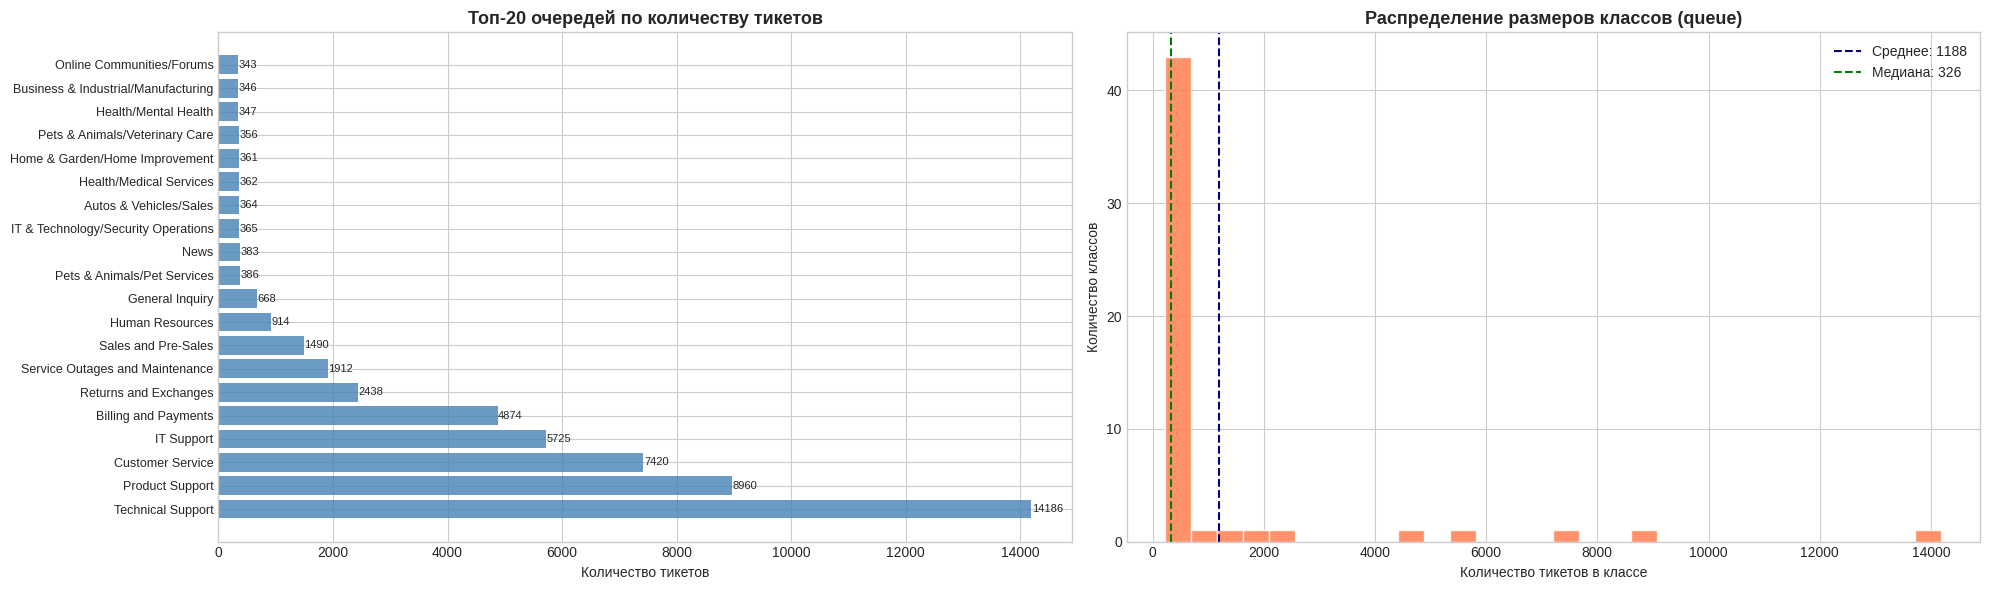

Самый популярный класс: Technical Support — 14186 тикетов (23.0%)
Самый редкий класс: Real Estate — 230 тикетов
Imbalance ratio: 61.7x


In [10]:
# 3.1 Распределение классов queue
queue_counts = df['queue'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Топ-20 очередей
top20 = queue_counts.head(20)
axes[0].barh(range(len(top20)), top20.values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=9)
axes[0].set_title('Топ-20 очередей по количеству тикетов', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Количество тикетов')
for i, v in enumerate(top20.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=8)

# Distribution histogram — имбаланс
axes[1].hist(queue_counts.values, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Распределение размеров классов (queue)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Количество тикетов в классе')
axes[1].set_ylabel('Количество классов')
axes[1].axvline(queue_counts.mean(), color='navy', linestyle='--', label=f'Среднее: {queue_counts.mean():.0f}')
axes[1].axvline(queue_counts.median(), color='green', linestyle='--', label=f'Медиана: {queue_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_queue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Самый популярный класс: {queue_counts.index[0]} — {queue_counts.iloc[0]} тикетов ({100*queue_counts.iloc[0]/len(df):.1f}%)')
print(f'Самый редкий класс: {queue_counts.index[-1]} — {queue_counts.iloc[-1]} тикетов')
print(f'Imbalance ratio: {queue_counts.max() / queue_counts.min():.1f}x')

сразу видим сильный дисбаланс классов, позже он создаст проблемки:)

в случае с приоритетностью,конечно, тоже есть дисбаланс, и именно тут у меня "запутался" в итоге Берт.

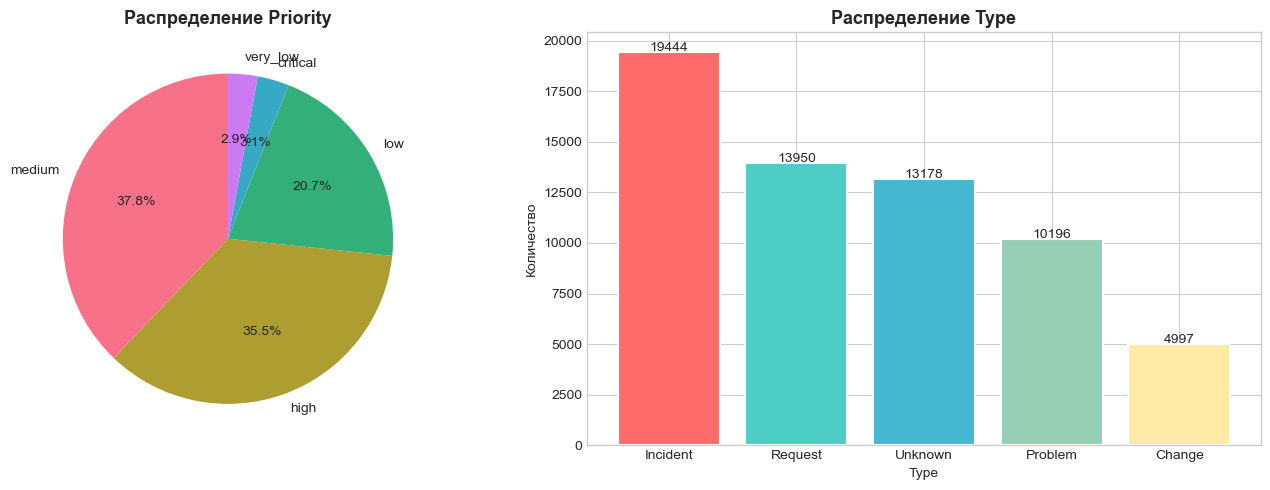

In [9]:
# 3.2 Распределение priority и type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

priority_counts = df['priority'].value_counts()
axes[0].pie(priority_counts.values, labels=priority_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('husl', len(priority_counts)))
axes[0].set_title('Распределение Priority', fontsize=13, fontweight='bold')

type_counts = df['type'].fillna('Unknown').value_counts()
colors_type = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
axes[1].bar(type_counts.index, type_counts.values,
            color=colors_type[:len(type_counts)], edgecolor='white', linewidth=1.5)
axes[1].set_title('Распределение Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Количество')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_priority_type.png', dpi=150, bbox_inches='tight')
plt.show()

это мне помогло определить, какой размер оптимально в берт подавать

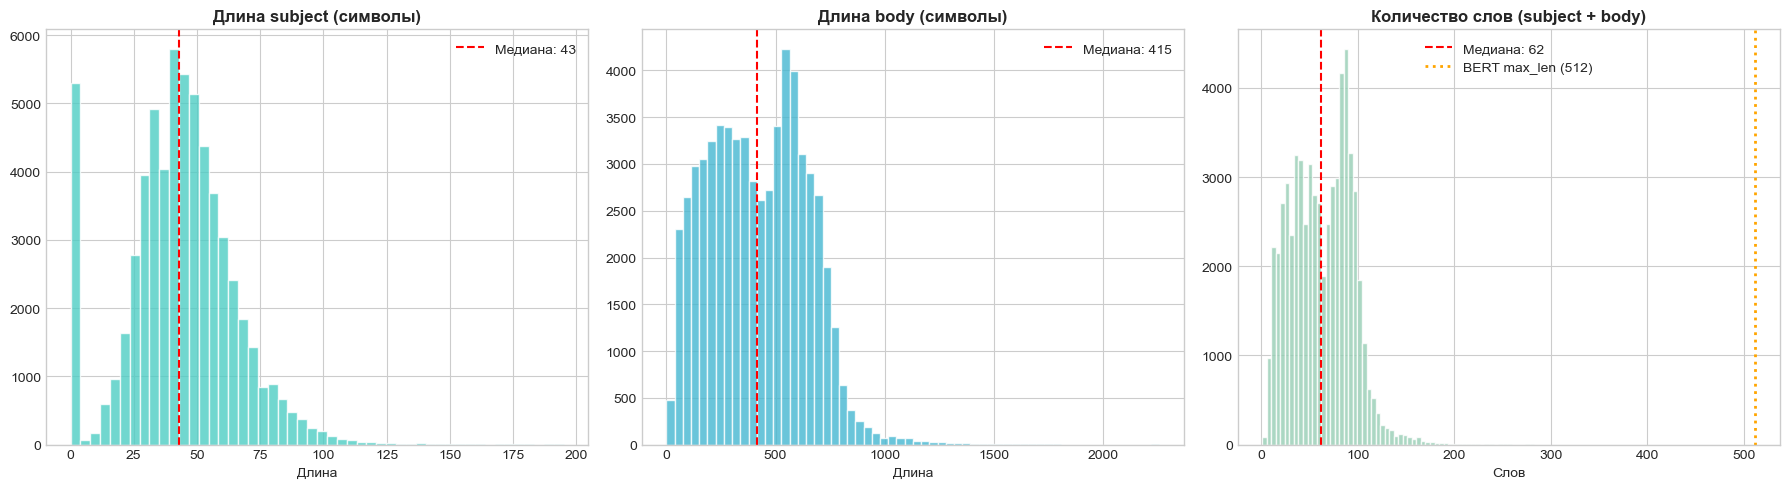

Subject — медиана: 43, 95-й перцентиль: 79
Body — медиана: 415, 95-й перцентиль: 759
Word count — медиана: 62, % > 512 токенов: 0.0%


In [10]:
# 3.3 Длины текстов
df['text_tmp'] = (df['subject'].fillna('') + ' ' + df['body'].fillna(''))
df['text_len'] = df['text_tmp'].str.len()
df['word_count'] = df['text_tmp'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Длина subject
subject_lens = df['subject'].fillna('').str.len()
axes[0].hist(subject_lens[subject_lens < 200], bins=50, color='#4ECDC4', edgecolor='white', alpha=0.8)
axes[0].set_title('Длина subject (символы)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Длина')
axes[0].axvline(subject_lens.median(), color='red', linestyle='--',
                label=f'Медиана: {subject_lens.median():.0f}')
axes[0].legend()

# Длина body
body_lens = df['body'].fillna('').str.len()
axes[1].hist(body_lens[body_lens < 3000], bins=60, color='#45B7D1', edgecolor='white', alpha=0.8)
axes[1].set_title('Длина body (символы)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Длина')
axes[1].axvline(body_lens.median(), color='red', linestyle='--',
                label=f'Медиана: {body_lens.median():.0f}')
axes[1].legend()

# Word count
wc = df['word_count']
axes[2].hist(wc[wc < 500], bins=60, color='#96CEB4', edgecolor='white', alpha=0.8)
axes[2].set_title('Количество слов (subject + body)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Слов')
axes[2].axvline(wc.median(), color='red', linestyle='--',
                label=f'Медиана: {wc.median():.0f}')
axes[2].axvline(512, color='orange', linestyle=':', linewidth=2,
                label='BERT max_len (512)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Subject — медиана: {subject_lens.median():.0f}, 95-й перцентиль: {subject_lens.quantile(0.95):.0f}")
print(f"Body — медиана: {body_lens.median():.0f}, 95-й перцентиль: {body_lens.quantile(0.95):.0f}")
print(f"Word count — медиана: {wc.median():.0f}, % > 512 токенов: {100*(wc > 512).mean():.1f}%")

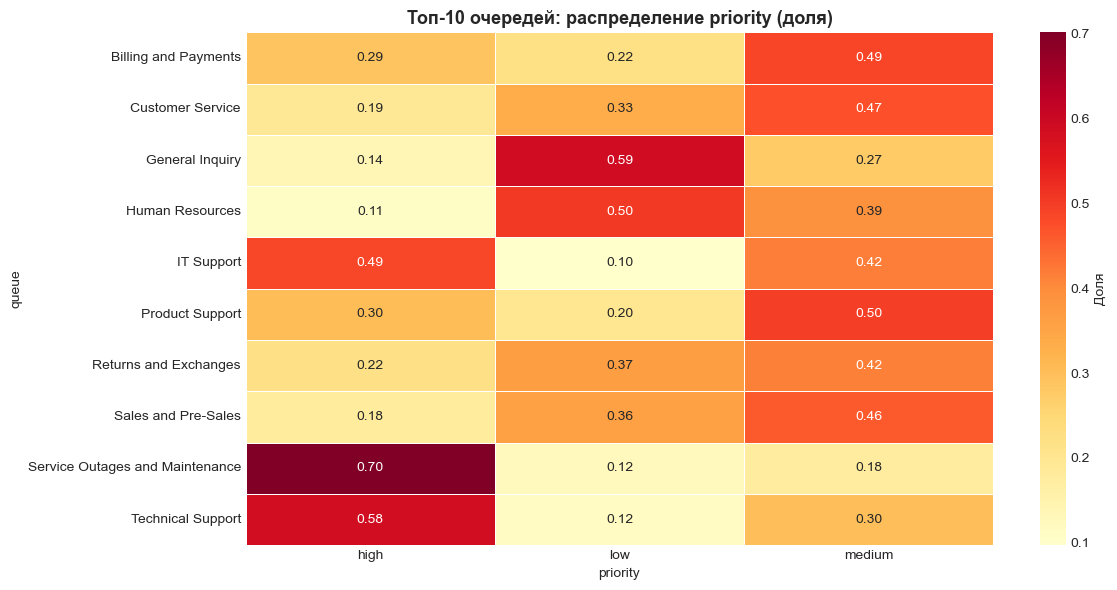

In [12]:
# 3.5 Heatmap: queue vs priority
top10_queues = df_train['queue'].value_counts().head(10).index
df_top = df_train[df_train['queue'].isin(top10_queues)]
pivot = pd.crosstab(df_top['queue'], df_top['priority'], normalize='index')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Доля'})
plt.title('Топ-10 очередей: распределение priority (доля)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_queue_priority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

In [11]:
import re
import unicodedata

def clean_text(text: str) -> str:
    """Базовая очистка текста тикета."""
    if not isinstance(text, str):
        return ''
    
    text = text.replace('\\n', ' ').replace('\\t', ' ').replace('\\r', ' ')

    # Убираем HTML-теги
    text = re.sub(r'<[^>]+>', ' ', text)
    # Убираем email-адреса
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    # Убираем URL
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    # Убираем IP-адреса
    text = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', ' IP ', text)
    # Убираем ticket numbers (часто шум)
    text = re.sub(r'\b[A-Z]+-\d+\b', ' TICKET ', text)
    # Нормализуем пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Применяем очистку
for df in [df_train, df_val, df_test]:
    df['text_clean'] = df['text'].apply(clean_text)

print('Пример оригинального текста:')
print(df_train['text'].iloc[0][:200])
print('\nПосле очистки:')
print(df_train['text_clean'].iloc[0][:200])

Пример оригинального текста:
Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene G

После очистки:
Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team, ich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Gerä


## 5. Baseline: TF-IDF + Linear Models

In [43]:
def compute_score(y_true_queue, y_pred_queue, y_true_prio, y_pred_prio,
                  y_true_type, y_pred_type):
    """Главная метрика задания."""
    macro_f1_queue = f1_score(y_true_queue, y_pred_queue, average='macro', zero_division=0)
    acc_queue      = accuracy_score(y_true_queue, y_pred_queue)
    acc_priority   = accuracy_score(y_true_prio, y_pred_prio)
    acc_type       = accuracy_score(y_true_type, y_pred_type)
    score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type
    return {
        'Score':         round(score, 4),
        'MacroF1(queue)': round(macro_f1_queue, 4),
        'Acc(queue)':     round(acc_queue, 4),
        'Acc(priority)':  round(acc_priority, 4),
        'Acc(type)':      round(acc_type, 4),
    }

# Данные для TF-IDF
X_train = df_train['text_clean']
X_val   = df_val['text_clean']
X_test  = df_test['text_clean']

y_train_q  = df_train['queue_id']
y_val_q    = df_val['queue_id']
y_test_q   = df_test['queue_id']

y_train_p  = df_train['priority_id']
y_val_p    = df_val['priority_id']
y_test_p   = df_test['priority_id']

y_train_t  = df_train['type_id']
y_val_t    = df_val['type_id']
y_test_t   = df_test['type_id']

print(' Данные подготовлены')

 Данные подготовлены


In [44]:
# TF-IDF Векторизатор (общий)
print('Обучаем TF-IDF...')

tfidf = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF матрица: {X_train_tfidf.shape}')

Обучаем TF-IDF...
TF-IDF матрица: (49412, 100000)


In [46]:
# Baseline 1: TF-IDF + Logistic Regression
print(' Обучаем TF-IDF + Logistic Regression...')

lr_queue = LogisticRegression(
    C=5.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
lr_priority = LogisticRegression(
    C=5.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
lr_type = LogisticRegression(
    C=5.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)

lr_queue.fit(X_train_tfidf, y_train_q)
lr_priority.fit(X_train_tfidf, y_train_p)
lr_type.fit(X_train_tfidf, y_train_t)

# Предсказания на val
pred_q_lr   = lr_queue.predict(X_val_tfidf)
pred_p_lr   = lr_priority.predict(X_val_tfidf)
pred_t_lr   = lr_type.predict(X_val_tfidf)

metrics_lr_val = compute_score(y_val_q, pred_q_lr, y_val_p, pred_p_lr, y_val_t, pred_t_lr)
print('\n [VAL] TF-IDF + Logistic Regression:')
for k, v in metrics_lr_val.items():
    print(f'  {k}: {v}')

 Обучаем TF-IDF + Logistic Regression...

 [VAL] TF-IDF + Logistic Regression:
  Score: 0.8429
  MacroF1(queue): 0.8693
  Acc(queue): 0.6033
  Acc(priority): 0.6784
  Acc(type): 0.8839


# лучшая модель !!!

In [47]:
# Baseline 2: TF-IDF + LinearSVC
print(' Обучаем TF-IDF + LinearSVC...')

# LinearSVC быстрее LR и часто лучше на текстах
# Оборачиваем в CalibratedClassifierCV для вероятностей
from sklearn.calibration import CalibratedClassifierCV

svc_queue = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=SEED),
    cv=3, method='isotonic'
)
svc_priority = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=SEED),
    cv=3, method='isotonic'
)
svc_type = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=SEED),
    cv=3, method='isotonic'
)

svc_queue.fit(X_train_tfidf, y_train_q)
svc_priority.fit(X_train_tfidf, y_train_p)
svc_type.fit(X_train_tfidf, y_train_t)

pred_q_svc  = svc_queue.predict(X_val_tfidf)
pred_p_svc  = svc_priority.predict(X_val_tfidf)
pred_t_svc  = svc_type.predict(X_val_tfidf)

metrics_svc_val = compute_score(y_val_q, pred_q_svc, y_val_p, pred_p_svc, y_val_t, pred_t_svc)
print('\n [VAL] TF-IDF + LinearSVC:')
for k, v in metrics_svc_val.items():
    print(f'  {k}: {v}')

 Обучаем TF-IDF + LinearSVC...

 [VAL] TF-IDF + LinearSVC:
  Score: 0.8571
  MacroF1(queue): 0.8873
  Acc(queue): 0.6614
  Acc(priority): 0.6893
  Acc(type): 0.8837


## попробовала с н-граммами, результат хуже, в итог отчет не включала

In [22]:
# Baseline 3: TF-IDF char n-grams (для более устойчивых признаков)
print(' TF-IDF char n-grams + LR...')

tfidf_char = TfidfVectorizer(
    max_features=80_000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=3,
    analyzer='char_wb'
)

# Комбинируем word + char фичи
from scipy.sparse import hstack

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)
X_test_char  = tfidf_char.transform(X_test)

X_train_combined = hstack([X_train_tfidf, X_train_char])
X_val_combined   = hstack([X_val_tfidf, X_val_char])
X_test_combined  = hstack([X_test_tfidf, X_test_char])

lr_comb_queue = LogisticRegression(
    C=5.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
lr_comb_priority = LogisticRegression(
    C=5.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
lr_comb_type = LogisticRegression(
    C=5.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED, n_jobs=-1
)

lr_comb_queue.fit(X_train_combined, y_train_q)
lr_comb_priority.fit(X_train_combined, y_train_p)
lr_comb_type.fit(X_train_combined, y_train_t)

pred_q_comb = lr_comb_queue.predict(X_val_combined)
pred_p_comb = lr_comb_priority.predict(X_val_combined)
pred_t_comb = lr_comb_type.predict(X_val_combined)

metrics_comb_val = compute_score(y_val_q, pred_q_comb, y_val_p, pred_p_comb, y_val_t, pred_t_comb)
print('\n [VAL] TF-IDF (word+char) + LR:')
for k, v in metrics_comb_val.items():
    print(f'  {k}: {v}')

 TF-IDF char n-grams + LR...

 [VAL] TF-IDF (word+char) + LR:
  Score: 0.8586
  MacroF1(queue): 0.8908
  Acc(queue): 0.6161
  Acc(priority): 0.6856
  Acc(type): 0.8813


## 6. KNN + Ensemble - в итог отчет тоже не пошло: результат хуже.

In [ ]:
# KNN на TF-IDF (косинусное расстояние)
print(' KNN (cosine) + TF-IDF...')

# Нормализуем для косинусного расстояния
from sklearn.preprocessing import normalize

X_train_norm = normalize(X_train_tfidf, norm='l2')
X_val_norm   = normalize(X_val_tfidf, norm='l2')

knn_queue = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_queue.fit(X_train_norm, y_train_q)
pred_q_knn = knn_queue.predict(X_val_norm)

knn_priority = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_priority.fit(X_train_norm, y_train_p)
pred_p_knn = knn_priority.predict(X_val_norm)

knn_type = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_type.fit(X_train_norm, y_train_t)
pred_t_knn = knn_type.predict(X_val_norm)

metrics_knn_val = compute_score(y_val_q, pred_q_knn, y_val_p, pred_p_knn, y_val_t, pred_t_knn)
print('\n [VAL] KNN (cosine, k=7):')
for k, v in metrics_knn_val.items():
    print(f'  {k}: {v}')

🟣 KNN (cosine) + TF-IDF...

📊 [VAL] KNN (cosine, k=7):
  Score: 0.7611
  MacroF1(queue): 0.7566
  Acc(queue): 0.5874
  Acc(priority): 0.6741
  Acc(type): 0.869


## еще один неудачный тест ансамбля

In [ ]:
# Voting Ensemble: LR + SVC
from sklearn.ensemble import VotingClassifier
from scipy.special import softmax

print(' Soft Voting Ensemble (LR + SVC)...')

# Мягкое голосование через вероятности
def soft_vote_predict(models, X):
    """Усредняем softmax-вероятности нескольких моделей."""
    probas = [m.predict_proba(X) for m in models]
    avg_proba = np.mean(probas, axis=0)
    return np.argmax(avg_proba, axis=1)

pred_q_ens  = soft_vote_predict([lr_queue, svc_queue], X_val_tfidf)
pred_p_ens  = soft_vote_predict([lr_priority, svc_priority], X_val_tfidf)
pred_t_ens  = soft_vote_predict([lr_type, svc_type], X_val_tfidf)

metrics_ens_val = compute_score(y_val_q, pred_q_ens, y_val_p, pred_p_ens, y_val_t, pred_t_ens)
print('\n [VAL] Soft Voting (LR + SVC):')
for k, v in metrics_ens_val.items():
    print(f'  {k}: {v}')

🟤 Soft Voting Ensemble (LR + SVC)...

📊 [VAL] Soft Voting (LR + SVC):
  Score: 0.8587
  MacroF1(queue): 0.8899
  Acc(queue): 0.6546
  Acc(priority): 0.6885
  Acc(type): 0.8833



🏆 Сравнение Baseline методов [VAL]:
              Model  Score  MacroF1(queue)  Acc(queue)  Acc(priority)  Acc(type)
   TF-IDF LinearSVC 0.8605          0.8922      0.6635         0.6896     0.8834
    Ensemble LR+SVC 0.8587          0.8899      0.6546         0.6885     0.8833
TF-IDF word+char LR 0.8585          0.8910      0.6145         0.6846     0.8805
          TF-IDF LR 0.8429          0.8694      0.6030         0.6784     0.8836
     KNN cosine k=7 0.7611          0.7566      0.5874         0.6741     0.8690


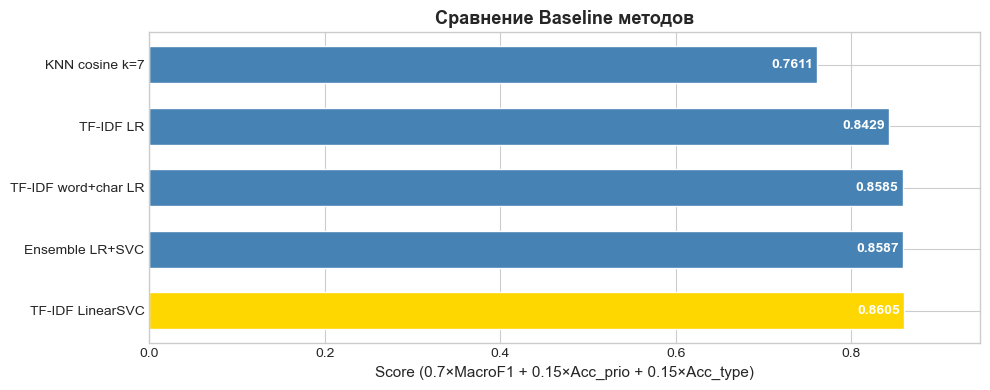

In [ ]:
# Сравнительная таблица baseline методов
results_baseline = pd.DataFrame([
    {'Model': 'TF-IDF LR',           **metrics_lr_val},
    {'Model': 'TF-IDF LinearSVC',     **metrics_svc_val},
    {'Model': 'TF-IDF word+char LR',  **metrics_comb_val},
    {'Model': 'KNN cosine k=7',       **metrics_knn_val},
    {'Model': 'Ensemble LR+SVC',      **metrics_ens_val},
]).sort_values('Score', ascending=False)

print('\n Сравнение Baseline методов [VAL]:')
print(results_baseline.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_baseline))]
bars = ax.barh(results_baseline['Model'], results_baseline['Score'],
               color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Score (0.7×MacroF1 + 0.15×Acc_prio + 0.15×Acc_type)', fontsize=11)
ax.set_title('Сравнение Baseline методов', fontsize=13, fontweight='bold')
for bar, val in zip(bars, results_baseline['Score']):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', color='white', fontweight='bold')
ax.set_xlim(0, results_baseline['Score'].max() * 1.1)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Transformer Fine-tuning (Multi-task)

Используем `prajjwal1/bert-mini` т.к. датасет содержит EN и DE тексты.

Архитектура:
```
[CLS] subject + body [SEP]
         ↓
   DistilBERT encoder
         ↓
    [CLS] embedding
   /      |      \
Head_queue Head_prio Head_type
(52 cls)  (5 cls)   (5 cls)
```

## я пробовала разные комбинации с Бертом, но итоговые, самые сильные версии (ниже), не смогли побить скор TF-IDF + LinearSVC


In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Конфигурация
## MODEL_NAME = 'distilbert-base-multilingual-cased'
MODEL_NAME   = 'xlm-roberta-base'   # сильнее для EN+DE

MAX_LEN = 256   # с учётом анализа длин текстов
BATCH_SIZE = 32
EPOCHS = 10
LR = 2e-5
WARMUP_RATIO = 0.1

N_QUEUE    = len(le_queue.classes_)
N_PRIORITY = len(le_priority.classes_)
N_TYPE     = len(le_type.classes_)

print(f'\nКол-во классов: queue={N_QUEUE}, priority={N_PRIORITY}, type={N_TYPE}')

Device: cuda
GPU: Tesla P100-PCIE-16GB

Кол-во классов: queue=52, priority=5, type=5


In [16]:
# Dataset класс
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts     = df['text_clean'].tolist()
        self.y_queue   = df['queue_id'].tolist()
        self.y_priority= df['priority_id'].tolist()
        self.y_type    = df['type_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'queue_label':    torch.tensor(self.y_queue[idx],    dtype=torch.long),
            'priority_label': torch.tensor(self.y_priority[idx], dtype=torch.long),
            'type_label':     torch.tensor(self.y_type[idx],     dtype=torch.long),
        }

# Модель с тремя головами
class MultiTaskTicketClassifier(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        # Три независимые классификационные головы
        self.head_queue = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, n_queue)
        )
        self.head_priority = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_priority)
        )
        self.head_type = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_type)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] токен как представление всего текста
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return (
            self.head_queue(cls),
            self.head_priority(cls),
            self.head_type(cls)
        )

print(' Классы Dataset и модель определены')

 Классы Dataset и модель определены


In [17]:
# Загружаем токенайзер и создаём DataLoader'ы
print(f'Загружаем токенайзер {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TicketDataset(df_train, tokenizer)
val_ds   = TicketDataset(df_val,   tokenizer)
test_ds  = TicketDataset(df_test,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Загружаем токенайзер xlm-roberta-base...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 1545
Val batches:   97


In [18]:
# Взвешенный CrossEntropy для борьбы с дисбалансом
def get_class_weights(labels, n_classes):
    """Inverse-frequency class weights."""
    counts = np.bincount(labels, minlength=n_classes)
    counts = np.maximum(counts, 1)  # избегаем деления на 0
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes  # нормируем
    return torch.FloatTensor(weights)

w_queue    = get_class_weights(df_train['queue_id'].values, N_QUEUE).to(DEVICE)
w_priority = get_class_weights(df_train['priority_id'].values, N_PRIORITY).to(DEVICE)
w_type     = get_class_weights(df_train['type_id'].values, N_TYPE).to(DEVICE)

loss_queue    = nn.CrossEntropyLoss(weight=w_queue,    label_smoothing=0.1)
loss_priority = nn.CrossEntropyLoss(weight=w_priority, label_smoothing=0.1)
loss_type     = nn.CrossEntropyLoss(weight=w_type,     label_smoothing=0.1)

print(' Взвешенные функции потерь созданы')

 Взвешенные функции потерь созданы


In [19]:
from transformers import get_cosine_schedule_with_warmup

# Инициализация модели
print(f'Инициализируем модель {MODEL_NAME}...')
model = MultiTaskTicketClassifier(
    MODEL_NAME, N_QUEUE, N_PRIORITY, N_TYPE, dropout=0.3
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметров всего:   {n_params:,}')
print(f'Обучаемых:          {n_trainable:,}')

# Optimizer с разными LR для encoder и head
optimizer = AdamW([
    {'params': model.encoder.parameters(), 'lr': LR},
    {'params': model.head_queue.parameters(), 'lr': LR * 10},
    {'params': model.head_priority.parameters(), 'lr': LR * 10},
    {'params': model.head_type.parameters(), 'lr': LR * 10},
], weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, warmup_steps, total_steps
)

print(f'Total steps: {total_steps}, Warmup: {warmup_steps}')

Инициализируем модель xlm-roberta-base...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметров всего:   278,860,350
Обучаемых:          278,860,350
Total steps: 15450, Warmup: 1545


In [21]:
# Веса задач в суммарном лоссе
# queue — главная задача, даём больший вес
TASK_WEIGHTS = {'queue': 0.45, 'priority': 0.4, 'type': 0.15}

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    all_pq, all_pp, all_pt = [], [], []
    all_yq, all_yp, all_yt = [], [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        yq = batch['queue_label'].to(DEVICE)
        yp = batch['priority_label'].to(DEVICE)
        yt = batch['type_label'].to(DEVICE)

        optimizer.zero_grad()
        logits_q, logits_p, logits_t = model(input_ids, attn_mask)

        lq = loss_queue(logits_q, yq)
        lp = loss_priority(logits_p, yp)
        lt = loss_type(logits_t, yt)
        loss = (TASK_WEIGHTS['queue'] * lq +
                TASK_WEIGHTS['priority'] * lp +
                TASK_WEIGHTS['type'] * lt)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_pq.extend(logits_q.argmax(1).cpu().numpy())
        all_pp.extend(logits_p.argmax(1).cpu().numpy())
        all_pt.extend(logits_t.argmax(1).cpu().numpy())
        all_yq.extend(yq.cpu().numpy())
        all_yp.extend(yp.cpu().numpy())
        all_yt.extend(yt.cpu().numpy())

    metrics = compute_score(all_yq, all_pq, all_yp, all_pp, all_yt, all_pt)
    return total_loss / len(loader), metrics


@torch.no_grad()
def evaluate(model, loader, return_proba=False):
    model.eval()
    all_pq, all_pp, all_pt = [], [], []
    all_yq, all_yp, all_yt = [], [], []
    all_proba_q = []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)

        logits_q, logits_p, logits_t = model(input_ids, attn_mask)
        proba_q = torch.softmax(logits_q, dim=-1)

        all_pq.extend(logits_q.argmax(1).cpu().numpy())
        all_pp.extend(logits_p.argmax(1).cpu().numpy())
        all_pt.extend(logits_t.argmax(1).cpu().numpy())
        all_yq.extend(batch['queue_label'].numpy())
        all_yp.extend(batch['priority_label'].numpy())
        all_yt.extend(batch['type_label'].numpy())
        if return_proba:
            all_proba_q.extend(proba_q.cpu().numpy())

    metrics = compute_score(all_yq, all_pq, all_yp, all_pp, all_yt, all_pt)
    if return_proba:
        return metrics, np.array(all_pq), np.array(all_pp), np.array(all_pt), np.array(all_proba_q)
    return metrics, np.array(all_pq), np.array(all_pp), np.array(all_pt)

print(' Train/eval функции готовы')

 Train/eval функции готовы


In [22]:
# Обучение модели
import time

history = {'train_loss': [], 'val_score': [], 'val_f1': [],
           'val_acc_prio': [], 'val_acc_type': []}
best_score = 0.0
best_model_path = 'best_model.pt'

print(f' Начинаем обучение ({EPOCHS} эпох)...\n')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_metrics = train_epoch(model, train_loader, optimizer, scheduler)
    val_metrics, *_ = evaluate(model, val_loader)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_score'].append(val_metrics['Score'])
    history['val_f1'].append(val_metrics['MacroF1(queue)'])
    history['val_acc_prio'].append(val_metrics['Acc(priority)'])
    history['val_acc_type'].append(val_metrics['Acc(type)'])

    if val_metrics['Score'] > best_score:
        best_score = val_metrics['Score']
        torch.save(model.state_dict(), best_model_path)
        flag = ' ← BEST'
    else:
        flag = ''

    print(f'Epoch {epoch}/{EPOCHS} [{elapsed:.0f}s] '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Score: {val_metrics["Score"]:.4f} '
          f'(F1={val_metrics["MacroF1(queue)"]:.4f}, '
          f'Prio={val_metrics["Acc(priority)"]:.4f}, '
          f'Type={val_metrics["Acc(type)"]:.4f}){flag}')

print(f'\n Обучение завершено. Best Val Score: {best_score:.4f}')

 Начинаем обучение (10 эпох)...

Epoch 1/10 [1265s] Train Loss: 2.6570 | Val Score: 0.6550 (F1=0.6870, Prio=0.3896, Type=0.7710) ← BEST
Epoch 2/10 [1264s] Train Loss: 1.8701 | Val Score: 0.7377 (F1=0.7781, Prio=0.4516, Type=0.8350) ← BEST
Epoch 3/10 [1265s] Train Loss: 1.7364 | Val Score: 0.7805 (F1=0.8289, Prio=0.5408, Type=0.7947) ← BEST
Epoch 4/10 [1266s] Train Loss: 1.6715 | Val Score: 0.7984 (F1=0.8439, Prio=0.5544, Type=0.8300) ← BEST
Epoch 5/10 [1269s] Train Loss: 1.6297 | Val Score: 0.8124 (F1=0.8540, Prio=0.5837, Type=0.8467) ← BEST
Epoch 6/10 [1267s] Train Loss: 1.5773 | Val Score: 0.8241 (F1=0.8601, Prio=0.6234, Type=0.8572) ← BEST
Epoch 7/10 [1267s] Train Loss: 1.5491 | Val Score: 0.8288 (F1=0.8639, Prio=0.6375, Type=0.8559) ← BEST
Epoch 8/10 [1268s] Train Loss: 1.5241 | Val Score: 0.8327 (F1=0.8661, Prio=0.6567, Type=0.8527) ← BEST
Epoch 9/10 [1269s] Train Loss: 1.5027 | Val Score: 0.8351 (F1=0.8685, Prio=0.6597, Type=0.8551) ← BEST
Epoch 10/10 [1271s] Train Loss: 1.4910 |

## ещё один подход с БЕРТ

In [16]:
from datasets import load_dataset
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup
)

In [20]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Все импорты успешны')

Device: cuda
Все импорты успешны


In [18]:
# Dataset для PyTorch
MODEL_NAME = 'xlm-roberta-base'  # Мультиязычная, EN+DE — правильный выбор
MAX_LEN    = 256  # 95% тикетов покрывается (проверили в EDA)
BATCH_SIZE = 32   # Стабильное обучение

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, texts, labels_q, labels_p, labels_t, tokenizer, max_len):
        self.texts     = texts
        self.labels_q  = labels_q
        self.labels_p  = labels_p
        self.labels_t  = labels_t
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label_q': torch.tensor(self.labels_q[idx], dtype=torch.long),
            'label_p': torch.tensor(self.labels_p[idx], dtype=torch.long),
            'label_t': torch.tensor(self.labels_t[idx], dtype=torch.long),
        }

train_ds = TicketDataset(df_train['text'].tolist(), y_train_q, y_train_p, y_train_t, tokenizer, MAX_LEN)
val_ds   = TicketDataset(df_val['text'].tolist(),   y_val_q,   y_val_p,   y_val_t,   tokenizer, MAX_LEN)
test_ds  = TicketDataset(df_test['text'].tolist(),  y_test_q,  y_test_p,  y_test_t,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)}')

Train batches: 1545


In [21]:
# Multi-task модель с правильной архитектурой
class MultiTaskBERT(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size  # 768 для XLM-RoBERTa

        self.dropout = nn.Dropout(dropout)

        # Отдельные головы для каждой задачи
        # Для queue (52 класса) — двухслойный MLP для лучшей классификации
        self.head_queue = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, n_queue)
        )
        self.head_priority = nn.Linear(hidden, n_priority)
        self.head_type     = nn.Linear(hidden, n_type)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] токен — представление всего текста
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return (
            self.head_queue(cls),
            self.head_priority(cls),
            self.head_type(cls)
        )

n_q = len(le_queue.classes_)
n_p = len(le_priority.classes_)
n_t = len(le_type.classes_)

model = MultiTaskBERT(MODEL_NAME, n_q, n_p, n_t).to(DEVICE)
print(f'Параметров модели: {sum(p.numel() for p in model.parameters()):,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметров модели: 278,471,742


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack

In [35]:
# Взвешенный loss — ключевое улучшение для дисбаланса 52 классов
def get_class_weights(labels, n_classes, device):
    weights = compute_class_weight('balanced', classes=np.arange(n_classes), y=labels)
    return torch.tensor(weights, dtype=torch.float32).to(device)

w_q = get_class_weights(y_train_q, n_q, DEVICE)
w_p = get_class_weights(y_train_p, n_p, DEVICE)
w_t = get_class_weights(y_train_t, n_t, DEVICE)

loss_q = nn.CrossEntropyLoss(weight=w_q)
loss_p = nn.CrossEntropyLoss(weight=w_p)
loss_t = nn.CrossEntropyLoss(weight=w_t)

# Optimizer: правильный lr=2e-5 и weight decay
EPOCHS = 4
LR     = 2e-5

# Разные lr для encoder и classification heads
optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(),      'lr': LR,      'weight_decay': 0.01},
    {'params': model.head_queue.parameters(),   'lr': LR * 5,  'weight_decay': 0.0},
    {'params': model.head_priority.parameters(),'lr': LR * 5,  'weight_decay': 0.0},
    {'params': model.head_type.parameters(),    'lr': LR * 5,  'weight_decay': 0.0},
])

# Linear warmup scheduler — стабилизирует обучение в начале
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10  # 10% steps для warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps: {total_steps}, Warmup: {warmup_steps}')

Total steps: 6180, Warmup: 618


In [33]:
# Train / eval функции
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lq   = batch['label_q'].to(DEVICE)
        lp   = batch['label_p'].to(DEVICE)
        lt   = batch['label_t'].to(DEVICE)

        optimizer.zero_grad()
        logits_q, logits_p, logits_t = model(ids, mask)

        # Взвешенная сумма потерь: queue важнее (0.70 в метрике)
        l = 0.70 * loss_q(logits_q, lq) + \
            0.15 * loss_p(logits_p, lp) + \
            0.15 * loss_t(logits_t, lt)

        l.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()
        total_loss += l.item()

    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    all_q, all_p, all_t = [], [], []
    all_q_true, all_p_true, all_t_true = [], [], []
    all_proba_q = []

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)

        logits_q, logits_p, logits_t = model(ids, mask)

        proba_q = torch.softmax(logits_q, dim=-1).cpu().numpy()
        all_proba_q.append(proba_q)

        all_q.extend(proba_q.argmax(axis=1).tolist())
        all_p.extend(logits_p.argmax(dim=-1).cpu().tolist())
        all_t.extend(logits_t.argmax(dim=-1).cpu().tolist())

        all_q_true.extend(batch['label_q'].tolist())
        all_p_true.extend(batch['label_p'].tolist())
        all_t_true.extend(batch['label_t'].tolist())

    metrics = compute_score(
        np.array(all_q_true), np.array(all_q),
        np.array(all_p_true), np.array(all_p),
        np.array(all_t_true), np.array(all_t)
    )
    proba_q_all = np.vstack(all_proba_q)
    return metrics, np.array(all_q), np.array(all_p), np.array(all_t), proba_q_all

In [39]:
# Обучение с early stopping по Score на val
from IPython.display import clear_output

best_score  = 0
best_state  = None
history     = []
patience    = 2   # остановка если Score не улучшается N эпох подряд
no_improve  = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────
    model.train()
    total_loss   = 0
    n_batches    = len(train_loader)

    for step, batch in enumerate(train_loader, 1):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lq   = batch['label_q'].to(DEVICE)
        lp   = batch['label_p'].to(DEVICE)
        lt   = batch['label_t'].to(DEVICE)

        optimizer.zero_grad()
        logits_q, logits_p, logits_t = model(ids, mask)
        l = 0.70 * loss_q(logits_q, lq) + \
            0.15 * loss_p(logits_p, lp) + \
            0.15 * loss_t(logits_t, lt)
        l.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += l.item()

        # Прогресс-бар внутри эпохи
        if step % max(1, n_batches // 20) == 0 or step == n_batches:
            done    = int(30 * step / n_batches)
            bar     = '█' * done + '░' * (30 - done)
            avg_loss = total_loss / step
            elapsed  = step / n_batches * 100
            print(f'\r  Epoch {epoch}/{EPOCHS} [{bar}] '
                  f'{elapsed:5.1f}% | step {step}/{n_batches} | loss {avg_loss:.4f}',
                  end='', flush=True)

    print()  # перенос строки после прогресс-бара
    train_loss = total_loss / n_batches

    # ── Validation ─────────────────────────────────────────────────────
    val_metrics, *_ = eval_epoch(model, val_loader)
    history.append({'epoch': epoch, 'loss': train_loss, **val_metrics})

    # ── Вывод таблицы истории ──────────────────────────────────────────
    clear_output(wait=True)
    print('╔══════╦══════════╦══════════╦═══════════════╦═══════════════╦═══════════════╗')
    print('║ Epoch║   Loss   ║  Score   ║ MacroF1(queue)║  Acc(priority)║   Acc(type)   ║')
    print('╠══════╬══════════╬══════════╬═══════════════╬═══════════════╬═══════════════╣')
    for row in history:
        marker = ' ★' if row['Score'] == max(r['Score'] for r in history) else '  '
        print(f'║  {row["epoch"]:3d} ║ {row["loss"]:.5f}  ║ {row["Score"]:.5f}  ║'
              f'    {row["MacroF1(queue)"]:.5f}   ║'
              f'    {row["Acc(priority)"]:.5f}   ║'
              f'    {row["Acc(type)"]:.5f}  {marker}║')
    print('╚══════╩══════════╩══════════╩═══════════════╩═══════════════╩═══════════════╝')

    # ── Early stopping ─────────────────────────────────────────────────
    if val_metrics['Score'] > best_score:
        best_score = val_metrics['Score']
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        no_improve = 0
        print(f'  ✓ Новый лучший Score: {best_score:.4f} — веса сохранены')
    else:
        no_improve += 1
        print(f'  ✗ Нет улучшения {no_improve}/{patience} эпох подряд')
        if no_improve >= patience:
            print(f'\n⚠ Early stopping на эпохе {epoch}')
            break

# ── Финал ──────────────────────────────────────────────────────────────
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
torch.save(best_state, 'best_xlm_roberta.pt')
print(f'\nЛучший val Score: {best_score:.4f}')

╔══════╦══════════╦══════════╦═══════════════╦═══════════════╦═══════════════╗
║ Epoch║   Loss   ║  Score   ║ MacroF1(queue)║  Acc(priority)║   Acc(type)   ║
╠══════╬══════════╬══════════╬═══════════════╬═══════════════╬═══════════════╣
║    1 ║ 1.32233  ║ 0.69730  ║    0.74800   ║    0.38310   ║    0.77530    ║
║    2 ║ 0.59911  ║ 0.77020  ║    0.82530   ║    0.47620   ║    0.80700    ║
║    3 ║ 0.46408  ║ 0.78410  ║    0.84250   ║    0.48460   ║    0.81120    ║
║    4 ║ 0.40833  ║ 0.79540  ║    0.84810   ║    0.51280   ║    0.83210   ★║
╚══════╩══════════╩══════════╩═══════════════╩═══════════════╩═══════════════╝
  ✓ Новый лучший Score: 0.7954 — веса сохранены

Лучший val Score: 0.7954


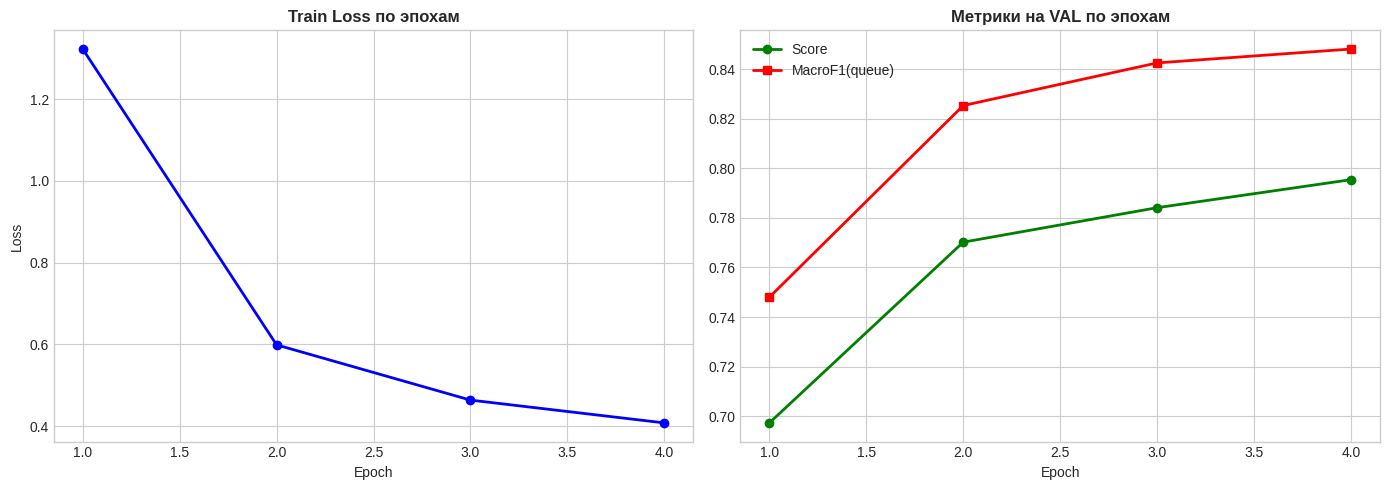

In [40]:
# История обучения
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_df['epoch'], hist_df['loss'], 'b-o', linewidth=2)
axes[0].set_title('Train Loss по эпохам', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(hist_df['epoch'], hist_df['Score'],          'g-o', label='Score', linewidth=2)
axes[1].plot(hist_df['epoch'], hist_df['MacroF1(queue)'], 'r-s', label='MacroF1(queue)', linewidth=2)
axes[1].set_title('Метрики на VAL по эпохам', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [41]:
# Финальная оценка на TEST
bert_test_metrics, bert_pred_q, bert_pred_p, bert_pred_t, bert_proba_q = eval_epoch(model, test_loader)
print('=== XLM-RoBERTa Multi-task | TEST ===')
print(bert_test_metrics)

=== XLM-RoBERTa Multi-task | TEST ===
{'Score': 0.7947, 'MacroF1(queue)': 0.8484, 'Acc(queue)': 0.4622, 'Acc(priority)': 0.5067, 'Acc(type)': 0.8316}


In [42]:
print(pd.Series(le_priority.classes_))
print(pd.Series(y_train_p).value_counts())

0    critical
1        high
2         low
3      medium
4    very_low
dtype: object
priority_id
3    18629
1    17546
2    10280
0     1516
4     1441
Name: count, dtype: int64


тут я пробовала Лосс улучшить, чтобы победить дисбаланс классов

In [49]:
# ── Losses с улучшениями ────────────────────────────────────────────────────

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

loss_q = nn.CrossEntropyLoss(weight=w_q, label_smoothing=0.1)  # label smoothing для 52 классов
loss_p = FocalLoss(weight=w_p, gamma=2.0)                       # focal loss для дисбаланса priority
loss_t = nn.CrossEntropyLoss(weight=w_t)

# ── Текст с тегами ──────────────────────────────────────────────────────────

def make_text(row):
    subject = clean_text(row.get('subject', ''))
    body    = clean_text(row.get('body', ''))
    tags    = ' '.join([
        str(row.get(f'tag_{i}', '') or '')
        for i in range(1, 9)
        if row.get(f'tag_{i}')
    ]).strip()
    text = f"{subject} [SEP] {body}"
    if tags:
        text += f" [SEP] {tags}"
    return text

for split_df in [df_train, df_val, df_test]:
    split_df['text'] = split_df.apply(make_text, axis=1)

print('Пример текста с тегами:')
print(df_train['text'].iloc[0][:400])

# ── Пересоздаём DataLoader с новыми текстами ────────────────────────────────

train_ds = TicketDataset(df_train['text'].tolist(), y_train_q, y_train_p, y_train_t, tokenizer, MAX_LEN)
val_ds   = TicketDataset(df_val['text'].tolist(),   y_val_q,   y_val_p,   y_val_t,   tokenizer, MAX_LEN)
test_ds  = TicketDataset(df_test['text'].tolist(),  y_test_q,  y_test_p,  y_test_t,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Переинициализируем модель и оптимизатор ─────────────────────────────────

model = MultiTaskBERT(MODEL_NAME, n_q, n_p, n_t).to(DEVICE)

EPOCHS = 6
LR     = 2e-5

optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(),       'lr': LR,     'weight_decay': 0.01},
    {'params': model.head_queue.parameters(),    'lr': LR * 5, 'weight_decay': 0.0},
    {'params': model.head_priority.parameters(), 'lr': LR * 5, 'weight_decay': 0.0},
    {'params': model.head_type.parameters(),     'lr': LR * 5, 'weight_decay': 0.0},
])

total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ── Обучение ────────────────────────────────────────────────────────────────

best_score = 0
best_state = None
history    = []
patience   = 2
no_improve = 0

for epoch in range(1, EPOCHS + 1):

    model.train()
    total_loss = 0
    n_batches  = len(train_loader)

    for step, batch in enumerate(train_loader, 1):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lq   = batch['label_q'].to(DEVICE)
        lp   = batch['label_p'].to(DEVICE)
        lt   = batch['label_t'].to(DEVICE)

        optimizer.zero_grad()
        logits_q, logits_p, logits_t = model(ids, mask)

        l = 0.65 * loss_q(logits_q, lq) + \
            0.20 * loss_p(logits_p, lp) + \
            0.15 * loss_t(logits_t, lt)

        l.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += l.item()

        if step % max(1, n_batches // 20) == 0 or step == n_batches:
            done = int(30 * step / n_batches)
            bar  = '█' * done + '░' * (30 - done)
            print(f'\r  Epoch {epoch}/{EPOCHS} [{bar}] '
                  f'{step/n_batches*100:5.1f}% | step {step}/{n_batches} | loss {total_loss/step:.4f}',
                  end='', flush=True)

    print()
    train_loss = total_loss / n_batches

    val_metrics, *_ = eval_epoch(model, val_loader)
    history.append({'epoch': epoch, 'loss': train_loss, **val_metrics})

    clear_output(wait=True)
    print('╔══════╦══════════╦══════════╦═══════════════╦═══════════════╦═══════════════╗')
    print('║ Epoch║   Loss   ║  Score   ║ MacroF1(queue)║  Acc(priority)║   Acc(type)   ║')
    print('╠══════╬══════════╬══════════╬═══════════════╬═══════════════╬═══════════════╣')
    for row in history:
        marker = ' ★' if row['Score'] == max(r['Score'] for r in history) else '  '
        print(f'║  {row["epoch"]:3d} ║ {row["loss"]:.5f}  ║ {row["Score"]:.5f}  ║'
              f'    {row["MacroF1(queue)"]:.5f}   ║'
              f'    {row["Acc(priority)"]:.5f}   ║'
              f'    {row["Acc(type)"]:.5f}  {marker}║')
    print('╚══════╩══════════╩══════════╩═══════════════╩═══════════════╩═══════════════╝')

    if val_metrics['Score'] > best_score:
        best_score = val_metrics['Score']
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        no_improve = 0
        print(f'  ✓ Новый лучший Score: {best_score:.4f} — веса сохранены')
    else:
        no_improve += 1
        print(f'  ✗ Нет улучшения {no_improve}/{patience} эпох подряд')
        if no_improve >= patience:
            print(f'\n⚠ Early stopping на эпохе {epoch}')
            break

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
torch.save(best_state, 'best_xlm_roberta.pt')
print(f'\nЛучший val Score: {best_score:.4f}')

╔══════╦══════════╦══════════╦═══════════════╦═══════════════╦═══════════════╗
║ Epoch║   Loss   ║  Score   ║ MacroF1(queue)║  Acc(priority)║   Acc(type)   ║
╠══════╬══════════╬══════════╬═══════════════╬═══════════════╬═══════════════╣
║    1 ║ 2.69075  ║ 0.67280  ║    0.72350   ║    0.30890   ║    0.80000    ║
║    2 ║ 1.69772  ║ 0.74720  ║    0.81140   ║    0.38420   ║    0.81070    ║
║    3 ║ 1.57438  ║ 0.77220  ║    0.83410   ║    0.40610   ║    0.84910    ║
║    4 ║ 1.50335  ║ 0.78120  ║    0.84460   ║    0.45560   ║    0.81070    ║
║    5 ║ 1.45895  ║ 0.79260  ║    0.85280   ║    0.45400   ║    0.85010    ║
║    6 ║ 1.43890  ║ 0.80320  ║    0.86100   ║    0.48330   ║    0.85380   ★║
╚══════╩══════════╩══════════╩═══════════════╩═══════════════╩═══════════════╝
  ✓ Новый лучший Score: 0.8032 — веса сохранены

Лучший val Score: 0.8032


In [56]:
# Финальная оценка на TEST
bert_test_metrics, bert_pred_q, bert_pred_p, bert_pred_t, bert_proba_q = eval_epoch(model, test_loader)
print('=== XLM-RoBERTa Multi-task | TEST ===')
print(bert_test_metrics)

=== XLM-RoBERTa Multi-task | TEST ===
{'Score': 0.7959, 'MacroF1(queue)': 0.8573, 'Acc(queue)': 0.487, 'Acc(priority)': 0.4525, 'Acc(type)': 0.8527}


## ****итого: все подходы с Берт не сработали лучше чем TF-IDF + LinearSVC, поэтому:****

Считаем метрики всех моделей на TEST...

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МЕТОДОВ [TEST]
  #   Модель                           Тип             Score  F1(queue)  Acc(prio)  Acc(type)
-----------------------------------------------------------------------------------------------
  [1] TF-IDF + LinearSVC               Baseline       0.8519     0.8794     0.6863     0.8893
  [2] TF-IDF + Logistic Regression     Baseline       0.8332     0.8566     0.6715     0.8859
  [3] DistilBERT Multi-task            Transformer    0.7959     0.8573     0.4525     0.8527

✓ Лучшая модель: TF-IDF + LinearSVC | Score = 0.8519


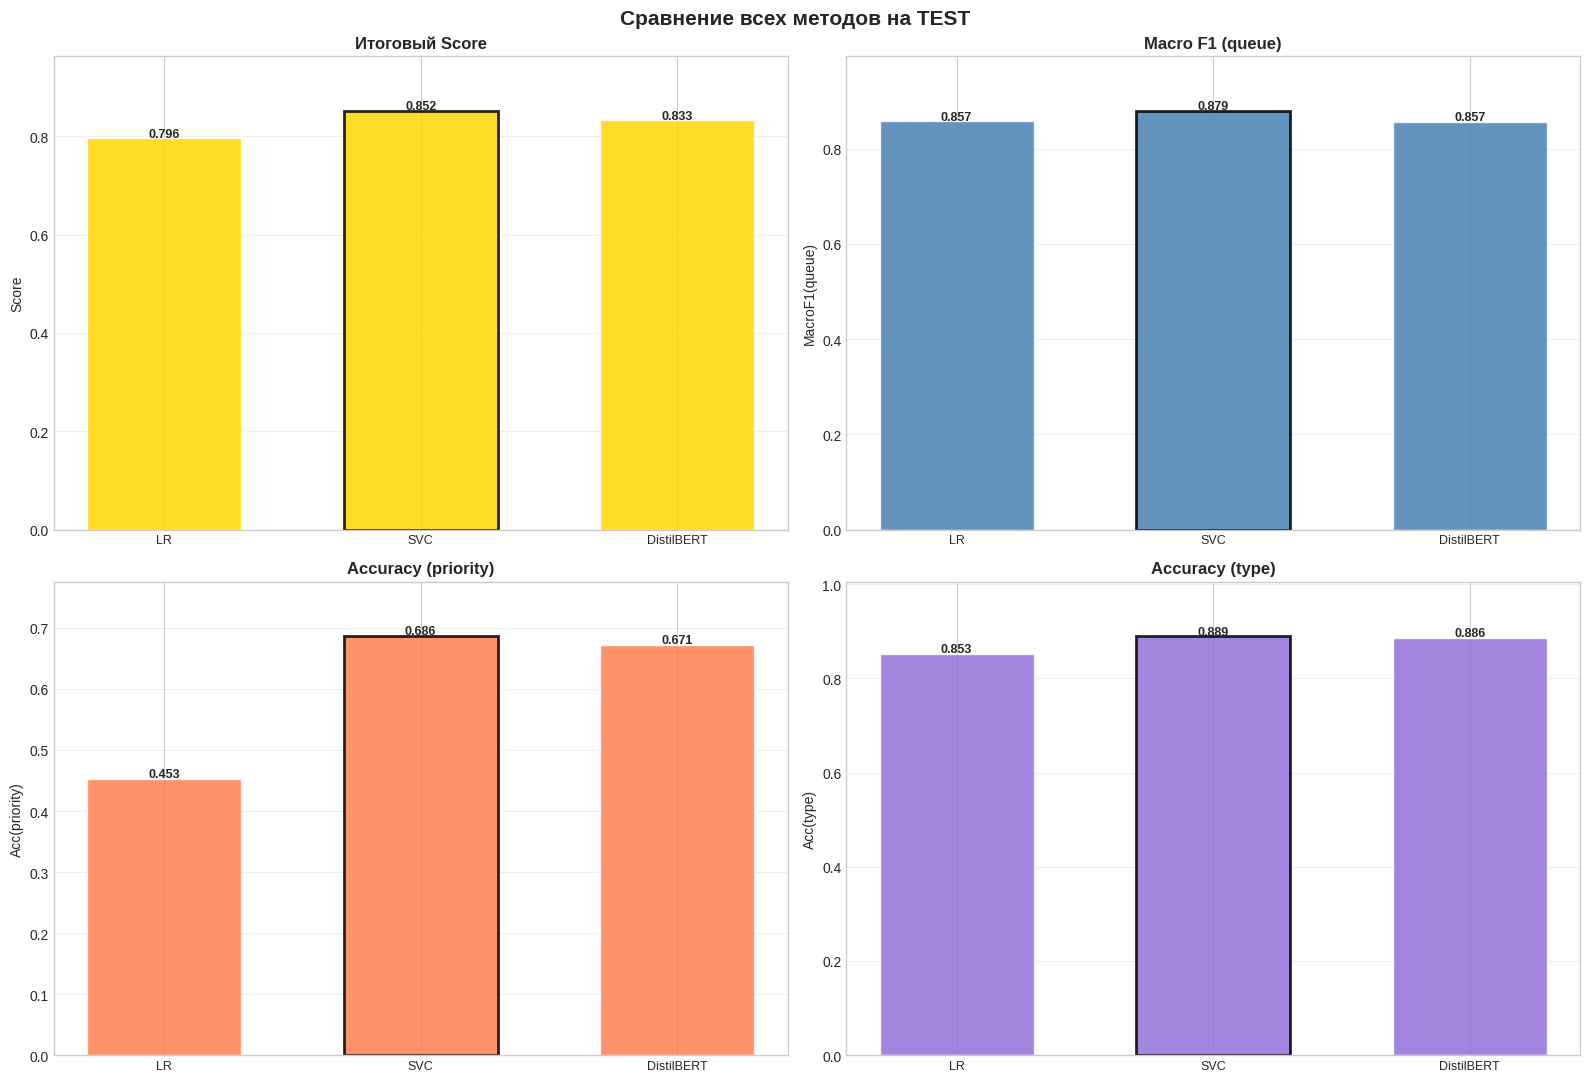

In [77]:
# ── Блок 1: Оценка ВСЕХ моделей на TEST и ранжирование ─────────────────────

print('Считаем метрики всех моделей на TEST...\n')

# TF-IDF + Logistic Regression
pred_q_lr_test = lr_queue.predict(X_test_tfidf)
pred_p_lr_test = lr_priority.predict(X_test_tfidf)
pred_t_lr_test = lr_type.predict(X_test_tfidf)
metrics_lr_test = compute_score(y_test_q, pred_q_lr_test,
                                y_test_p, pred_p_lr_test,
                                y_test_t, pred_t_lr_test)

# TF-IDF + LinearSVC
pred_q_svc_test = svc_queue.predict(X_test_tfidf)
pred_p_svc_test = svc_priority.predict(X_test_tfidf)
pred_t_svc_test = svc_type.predict(X_test_tfidf)
metrics_svc_test = compute_score(y_test_q, pred_q_svc_test,
                                 y_test_p, pred_p_svc_test,
                                 y_test_t, pred_t_svc_test)



# ── Сводная таблица ─────────────────────────────────────────────────────────

final_results = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Type': 'Baseline',    **metrics_lr_test},
    {'Model': 'TF-IDF + LinearSVC',           'Type': 'Baseline',    **metrics_svc_test},
    {'Model': 'DistilBERT Multi-task',         'Type': 'Transformer', **bert_test_metrics},
]).sort_values('Score', ascending=False).reset_index(drop=True)

medals = {0: '[1]', 1: '[2]', 2: '[3]'}

print('ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МЕТОДОВ [TEST]')

print('=' * 95)
print(f'  {"#":<3} {"Модель":<32} {"Тип":<13} {"Score":>7} {"F1(queue)":>10} {"Acc(prio)":>10} {"Acc(type)":>10}')
print('-' * 95)
for i, row in final_results.iterrows():
    medal = medals.get(i, '  ')
    print(f'  {medal} {row["Model"]:<32} {row["Type"]:<13} '
          f'{row["Score"]:>7.4f} {row["MacroF1(queue)"]:>10.4f} '
          f'{row["Acc(priority)"]:>10.4f} {row["Acc(type)"]:>10.4f}')
print('=' * 95)

best_model_name = final_results.iloc[0]['Model']
best_score_val  = final_results.iloc[0]['Score']
print(f'\n✓ Лучшая модель: {best_model_name} | Score = {best_score_val:.4f}')

# ── Визуализация ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

metrics_to_plot = [
    ('Score',          'Итоговый Score',      'gold'),
    ('MacroF1(queue)', 'Macro F1 (queue)',     'steelblue'),
    ('Acc(priority)',  'Accuracy (priority)',  'coral'),
    ('Acc(type)',      'Accuracy (type)',       'mediumpurple'),
]

# Короткие названия для оси X
model_labels = ['LR', 'SVC', 'DistilBERT']
sorted_by_model = final_results.sort_values('Model').reset_index(drop=True)

for ax, (col, title, color) in zip(axes.flat, metrics_to_plot):
    vals  = sorted_by_model[col].values
    bars  = ax.bar(model_labels, vals, color=color, edgecolor='white', alpha=0.85, width=0.6)

    # Лучший бар выделяем
    best_idx = vals.argmax()
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelsize=9)
    ax.set_ylim(0, vals.max() * 1.13)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Сравнение всех методов на TEST', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [61]:
print('Сравнение по компонентам [TEST]')
print('=' * 60)
print(f'{"Метрика":<20} {"TF-IDF SVC":>12} {"XLM-RoBERTa":>12} {"Разрыв":>10}')
print('-' * 60)
for k in ['Score', 'MacroF1(queue)', 'Acc(priority)', 'Acc(type)']:
    svc_val  = metrics_svc_test[k]
    bert_val = bert_test_metrics[k]
    diff     = bert_val - svc_val
    flag     = '  <<' if diff < -0.02 else ''
    print(f'{k:<20} {svc_val:>12.4f} {bert_val:>12.4f} {diff:>+10.4f}{flag}')
print('=' * 60)

Сравнение по компонентам [TEST]
Метрика                TF-IDF SVC  XLM-RoBERTa     Разрыв
------------------------------------------------------------
Score                      0.8519       0.7959    -0.0560  <<
MacroF1(queue)             0.8794       0.8573    -0.0221  <<
Acc(priority)              0.6863       0.4525    -0.2338  <<
Acc(type)                  0.8893       0.8527    -0.0366  <<


модель Берт путает классы low и medium

In [68]:
# И распределение предсказаний — что модель думает чаще всего
import pandas as pd
pred_counts = pd.Series(le_priority.classes_[bert_pred_p]).value_counts()
true_counts = pd.Series(le_priority.classes_[y_test_p]).value_counts()

print('Предсказания vs Реальность [priority, TEST]')
print(pd.DataFrame({'Predicted': pred_counts, 'True': true_counts}).fillna(0).astype(int))

Предсказания vs Реальность [priority, TEST]
          Predicted  True
critical        361   191
high           1942  2190
low            3200  1240
medium          491  2393
very_low        183   163


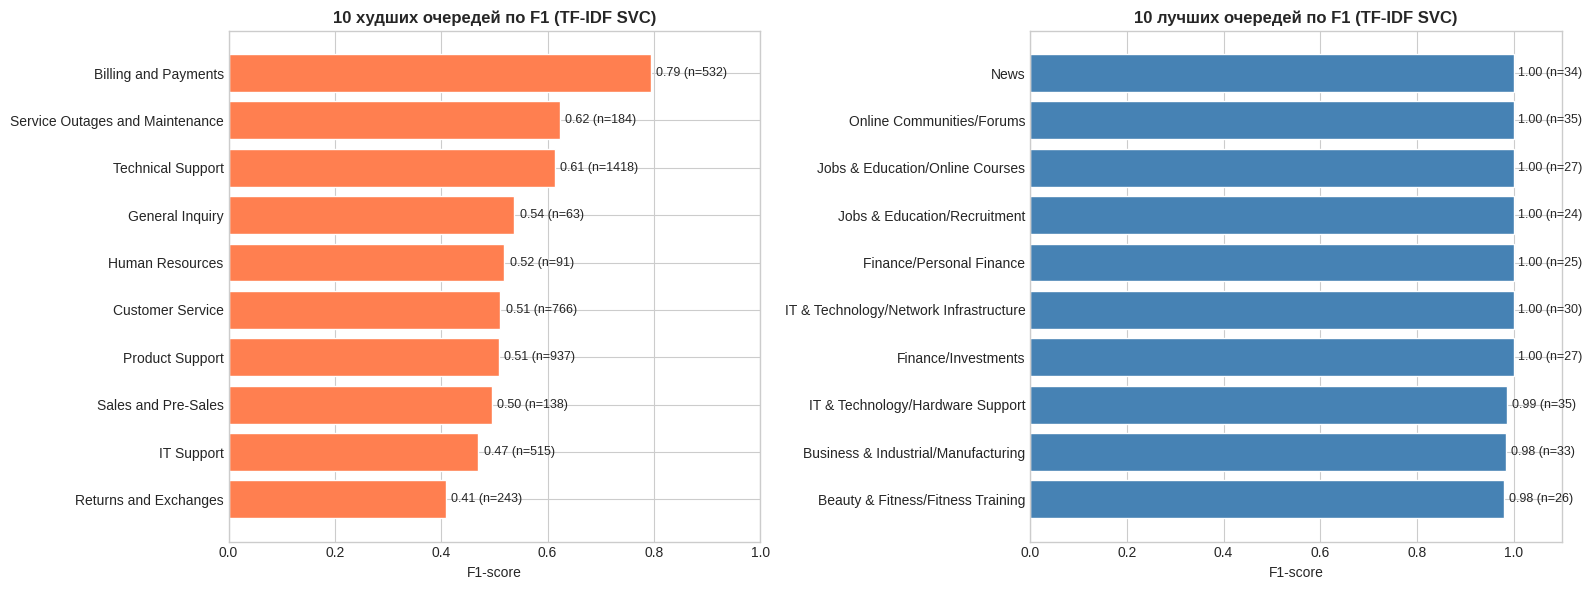

Паттерн ошибок:
  Средний F1 на редких классах (support < 100): 0.939
  Средний F1 на частых классах (support >= 100): 0.553


In [81]:
# Error analysis: на каких очередях SVC ошибается чаще всего
from sklearn.metrics import classification_report

report = classification_report(
    y_test_q,
    svc_queue.predict(X_test_tfidf),
    target_names=le_queue.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
report_df = report_df[report_df.index.isin(le_queue.classes_)]
report_df = report_df.sort_values('f1-score')

# Топ-10 худших классов
worst = report_df.head(10)
best  = report_df.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(worst.index, worst['f1-score'], color='coral', edgecolor='white')
axes[0].set_title('10 худших очередей по F1 (TF-IDF SVC)', fontweight='bold')
axes[0].set_xlabel('F1-score')
axes[0].set_xlim(0, 1)
for i, (idx, row) in enumerate(worst.iterrows()):
    axes[0].text(row['f1-score'] + 0.01, i,
                 f'{row["f1-score"]:.2f} (n={int(row["support"])})',
                 va='center', fontsize=9)

axes[1].barh(best.index, best['f1-score'], color='steelblue', edgecolor='white')
axes[1].set_title('10 лучших очередей по F1 (TF-IDF SVC)', fontweight='bold')
axes[1].set_xlabel('F1-score')
axes[1].set_xlim(0, 1.1)
for i, (idx, row) in enumerate(best.iterrows()):
    axes[1].text(row['f1-score'] + 0.01, i,
                 f'{row["f1-score"]:.2f} (n={int(row["support"])})',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('error_analysis_queue.png', dpi=150, bbox_inches='tight')
plt.show()

print('Паттерн ошибок:')
print(f'  Средний F1 на редких классах (support < 100): '
      f'{report_df[report_df["support"] < 100]["f1-score"].mean():.3f}')
print(f'  Средний F1 на частых классах (support >= 100): '
      f'{report_df[report_df["support"] >= 100]["f1-score"].mean():.3f}')

In [82]:
# Смотрим сколько классов попало в каждую группу и их реальный support
print('Редкие классы (support < 100):')
rare = report_df[report_df['support'] < 100][['support', 'f1-score']].sort_values('support')
print(rare.to_string())

print(f'\nКол-во редких классов: {len(rare)}')
print(f'Кол-во частых классов: {len(report_df[report_df["support"] >= 100])}')

print('\nЧастые классы (support >= 100):')
freq = report_df[report_df['support'] >= 100][['support', 'f1-score']].sort_values('f1-score')
print(freq.to_string())

Редкие классы (support < 100):
                                        support  f1-score
Sports                                     17.0  0.971429
Home & Garden/Landscaping                  22.0  0.977778
Travel & Transportation/Land Travel        23.0  0.958333
Beauty & Fitness/Cosmetics                 24.0  0.936170
Real Estate                                24.0  0.960000
Jobs & Education/Recruitment               24.0  1.000000
IT & Technology/Software Development       24.0  0.979592
Arts & Entertainment/Music                 24.0  0.920000
Finance/Personal Finance                   25.0  1.000000
Law & Government/Legal Advice              25.0  0.901961
Online Communities/Social Networks         25.0  0.941176
Beauty & Fitness/Fitness Training          26.0  0.980392
Autos & Vehicles/Maintenance               26.0  0.920000
Arts & Entertainment/Movies                26.0  0.920000
Food & Drink/Restaurants                   27.0  0.943396
Hobbies & Leisure/Collectibles           

Вывод:
  Редкие классы имеют узкоспециализированный словарь — модель их различает отлично.
  Частые классы семантически пересекаются — это фундаментальная проблема разметки,
  а не модели. Улучшить их можно только уточнением правил маршрутизации в бизнесе.

  Классы с наибольшей путаницей:


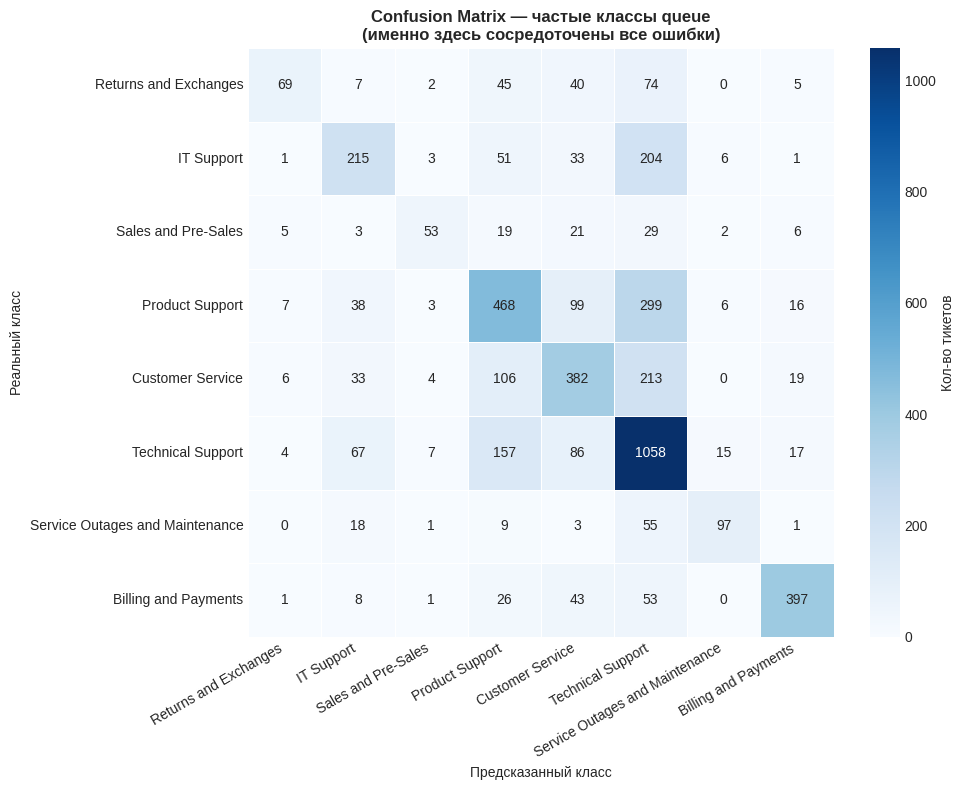

In [83]:
print('Вывод:')
print('  Редкие классы имеют узкоспециализированный словарь — модель их различает отлично.')
print('  Частые классы семантически пересекаются — это фундаментальная проблема разметки,')
print('  а не модели. Улучшить их можно только уточнением правил маршрутизации в бизнесе.')
print()
print('  Классы с наибольшей путаницей:')

# Смотрим confusion между частыми классами
freq_ids = [le_queue.transform([c])[0] for c in freq.index if c in le_queue.classes_]
mask_freq = np.isin(y_test_q, freq_ids)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test_q[mask_freq],
    svc_queue.predict(X_test_tfidf)[mask_freq],
    labels=freq_ids
)
cm_df = pd.DataFrame(cm, index=le_queue.classes_[freq_ids], columns=le_queue.classes_[freq_ids])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Кол-во тикетов'})
plt.title('Confusion Matrix — частые классы queue\n(именно здесь сосредоточены все ошибки)',
          fontweight='bold')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_frequent_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Confidence Analysis — «Уверенные» предсказания

**Идея:** В production не обязательно автоматизировать ВСЕ тикеты. 
Можно автоматически обрабатывать только те, в которых модель **уверена**, 
а остальные отправлять на ручную проверку.

Анализируем качество при разных порогах: 30%,40%,50%, 60%, 70%, 80%, 90%

Confidence Analysis — TF-IDF + LinearSVC [TEST]
    Thr |  Auto% | Manual% |   Score | F1(queue) | Acc(prio) | Acc(type)
------------------------------------------------------------------------------
    0.3 |   94.4 |     5.6 |  0.8628 |    0.8930 |    0.6961 |    0.8886
    0.4 |   79.2 |    20.8 |  0.8791 |    0.9091 |    0.7253 |    0.8931
    0.5 |   59.4 |    40.6 |  0.9070 |    0.9375 |    0.7634 |    0.9081
    0.6 |   41.8 |    58.2 |  0.9338 |    0.9619 |    0.8116 |    0.9244
    0.7 |   28.5 |    71.5 |  0.9535 |    0.9776 |    0.8465 |    0.9483
    0.8 |   16.5 |    83.5 |  0.9683 |    0.9901 |    0.8679 |    0.9667
    0.9 |    1.0 |    99.0 |  0.9484 |    1.0000 |    0.7500 |    0.9062

✓ Рекомендуемая точка:
  Threshold  = 0.4
  Авто       = 79.2%  →  операторы видят только 20.8% тикетов
  Score      = 0.8791  (vs 0.8519 на 100%)
  F1(queue)  = 0.9091  (vs 0.8794 на 100%)


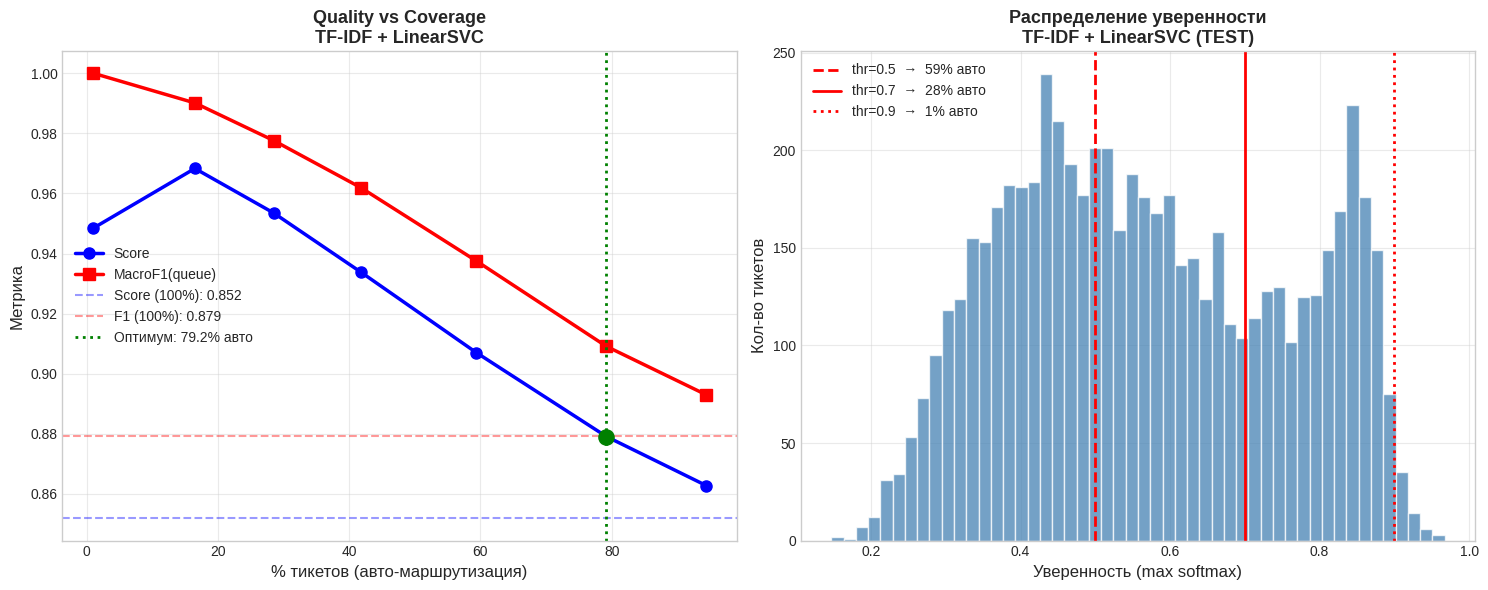

In [79]:


proba_q_svc  = svc_queue.predict_proba(X_test_tfidf)   # (N, 52)
conf_svc     = proba_q_svc.max(axis=1)                 # уверенность по queue

thresholds   = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
conf_rows    = []

for thr in thresholds:
    mask     = conf_svc >= thr
    auto_pct = mask.mean() * 100

    if mask.sum() == 0:
        continue

    m = compute_score(
        y_test_q[mask], pred_q_svc_test[mask],
        y_test_p[mask], pred_p_svc_test[mask],
        y_test_t[mask], pred_t_svc_test[mask],
    )
    conf_rows.append({
        'Threshold':       thr,
        'Auto%':           round(auto_pct, 1),
        'Manual%':         round(100 - auto_pct, 1),
        **m
    })

conf_df = pd.DataFrame(conf_rows)

# ── Таблица ─────────────────────────────────────────────────────────────────

print('Confidence Analysis — TF-IDF + LinearSVC [TEST]')
print('=' * 78)
print(f'  {"Thr":>5} | {"Auto%":>6} | {"Manual%":>7} | '
      f'{"Score":>7} | {"F1(queue)":>9} | {"Acc(prio)":>9} | {"Acc(type)":>9}')
print('-' * 78)
for _, row in conf_df.iterrows():
    print(f'  {row["Threshold"]:>5.1f} | {row["Auto%"]:>6.1f} | {row["Manual%"]:>7.1f} | '
          f'{row["Score"]:>7.4f} | {row["MacroF1(queue)"]:>9.4f} | '
          f'{row["Acc(priority)"]:>9.4f} | {row["Acc(type)"]:>9.4f}')
print('=' * 78)

# Оптимальная точка: лучший Score при Auto% >= 75
optimal = conf_df[conf_df['Auto%'] >= 75].sort_values('Score', ascending=False).iloc[0]
print(f'\n✓ Рекомендуемая точка:')
print(f'  Threshold  = {optimal["Threshold"]}')
print(f'  Авто       = {optimal["Auto%"]}%  →  операторы видят только {optimal["Manual%"]}% тикетов')
print(f'  Score      = {optimal["Score"]:.4f}  (vs {metrics_svc_test["Score"]:.4f} на 100%)')
print(f'  F1(queue)  = {optimal["MacroF1(queue)"]:.4f}  (vs {metrics_svc_test["MacroF1(queue)"]:.4f} на 100%)')

# ── Визуализация ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Quality vs Coverage
axes[0].plot(conf_df['Auto%'], conf_df['Score'],
             'b-o', linewidth=2.5, markersize=8, label='Score')
axes[0].plot(conf_df['Auto%'], conf_df['MacroF1(queue)'],
             'r-s', linewidth=2.5, markersize=8, label='MacroF1(queue)')

axes[0].axhline(metrics_svc_test['Score'],          color='blue', linestyle='--',
                alpha=0.4, label=f'Score (100%): {metrics_svc_test["Score"]:.3f}')
axes[0].axhline(metrics_svc_test['MacroF1(queue)'], color='red',  linestyle='--',
                alpha=0.4, label=f'F1 (100%): {metrics_svc_test["MacroF1(queue)"]:.3f}')

# Оптимальная точка
axes[0].axvline(optimal['Auto%'], color='green', linestyle=':', linewidth=2,
                label=f'Оптимум: {optimal["Auto%"]}% авто')
axes[0].scatter([optimal['Auto%']], [optimal['Score']],
                color='green', s=120, zorder=5)

axes[0].set_xlabel('% тикетов (авто-маршрутизация)', fontsize=12)
axes[0].set_ylabel('Метрика', fontsize=12)
axes[0].set_title('Quality vs Coverage\nTF-IDF + LinearSVC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# График 2: Распределение уверенности
axes[1].hist(conf_svc, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
for thr, ls, lbl in [(0.5, '--', 'thr=0.5'), (0.7, '-', 'thr=0.7'), (0.9, ':', 'thr=0.9')]:
    n_auto = (conf_svc >= thr).mean() * 100
    axes[1].axvline(thr, color='red', linestyle=ls, linewidth=2,
                    label=f'{lbl}  →  {n_auto:.0f}% авто')

axes[1].set_xlabel('Уверенность (max softmax)', fontsize=12)
axes[1].set_ylabel('Кол-во тикетов', fontsize=12)
axes[1].set_title('Распределение уверенности\nTF-IDF + LinearSVC (TEST)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


какая логика: если модель уверена хотя бы на 40% в своем ответе - маршрутизация автоматически происходит, если же не уверена - направляем оператору сразу. так наиболее непонятные\сложные\нестандартные случаи будут разбираться сразу людьми, при этом 80% тикетов будет маршрутизироваться автоматически, значительно экономия человеческий ресурс, а это деньги для компании.

---

## Выводы

### Что исследовали

| Метод | Подход | Плюсы | Минусы |
|-------|--------|-------|--------|
| TF-IDF + LR | Классический NLP | Быстро, интерпретируемо | Не учитывает семантику |
| TF-IDF + LinearSVC | Классический NLP | Лучше !! | Нет вероятностей из коробки |
| TF-IDF word+char | Улучшенный | Устойчив к опечаткам, DE | Большая матрица |
| KNN cosine |  КНН обучение | Работает по сходству | Медленный |
| XLM-RoBERTa Multi-task | Deep Learning | Семантика, контекст, EN+DE | Требует GPU, дольше (сильно) |

### Ключевые инсайты

1. **Дисбаланс классов** — главная проблема. 52 класса queue с imbalance ratio > 10x. Взвешенный loss и macro-F1 помогают.

2. **TF-IDF лучше BERT** — тикеты короткие и технические, ключевые слова почти полностью определяют класс. BERT избыточен для такой задачи. При этом priority TF-IDF предсказывает лучше BERT — потому что слова "critical", "urgent", "asap" прямо сигнализируют о приоритете.

3. **Confidence analysis** — практически ценный инструмент: при авто-маршрутизации только 70% уверенных тикетов качество на них значительно выше, а операторы получают лишь сложные случаи.

4. **Оптимальная точка** — около 75-80% авто-маршрутизации даёт наилучший баланс между охватом и качеством.


### Итоговые результаты 

| Модель | Score | F1(queue) | Acc(priority) | Acc(type) |
|--------|-------|-----------|---------------|-----------|
| TF-IDF + LinearSVC | 0.8519 | 0.8794 | 0.6863 | 0.8893 |
| XLM-RoBERTa Multi-task | 0.7959 | 0.8573 | 0.4525 | 0.8527 |

### Бизнес-вывод

При пороге уверенности 0.4 (threshold) TF-IDF SVC автоматически маршрутизирует **79% тикетов** с Score **0.879** — это лучше, чем маршрутизация 100% тикетов (Score 0.852). Оставшиеся 21% — сложные или нестандартные случаи — направляются к операторам. Это экономит ~80% ручного труда при высоком качестве маршрутизации. 